RQ3 – Customer segment differences across regions

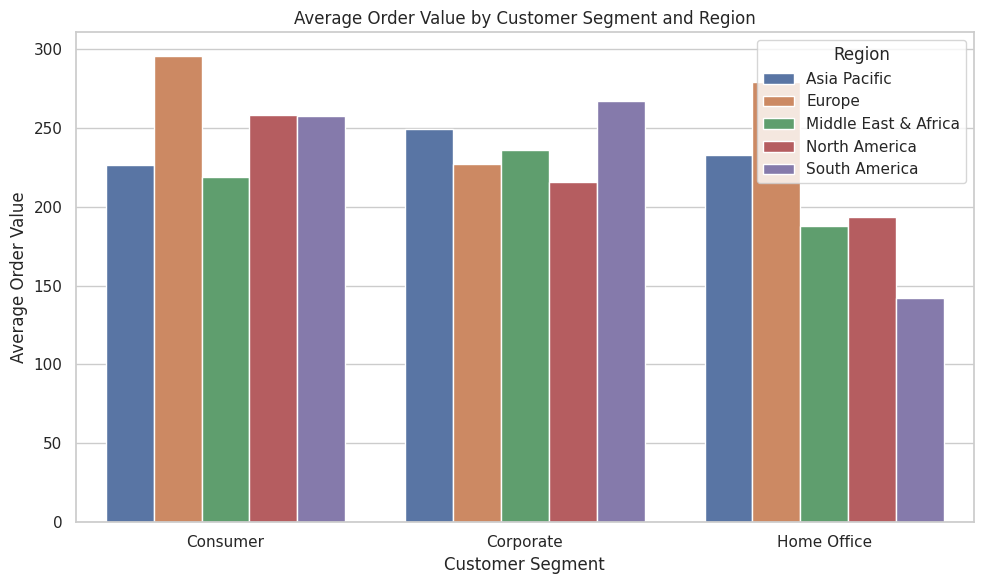

In [10]:
# RQ3: Customer segment differences across regions

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -------------------
# 1. Load data
# -------------------
DATA_PATH = Path("/kaggle/input/datasets/bibirehana/global-e-commarce-sales-data-analysis/global_ecommerce_sales.csv")
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = Path("./rq3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------
# 2. Aggregate by Region and Customer_Segment
# -------------------
seg_region = (
    df.groupby(['Region', 'Customer_Segment'], as_index=False)
      .agg(
          Avg_Order_Value=('Total_Sales', 'mean'),
          Avg_Profit=('Profit', 'mean'),
          Order_Count=('Order_ID', 'nunique')
      )
)

seg_region.to_csv(OUTPUT_DIR / "RQ3_Table_Segment_Region_AOV_Profit.csv", index=False)

# -------------------
# 3. Plot grouped bar chart
# -------------------
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=seg_region,
    x='Customer_Segment',
    y='Avg_Order_Value',
    hue='Region'
)
plt.title("Average Order Value by Customer Segment and Region")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RQ3_Figure1_Segment_Region_AOV.pdf", format="pdf")
plt.show()
plt.close()

### Interpretation of chart.

- Asia Pacific shows the highest Average Order Value (AOV) across all customer segments, indicating stronger purchasing power or higher‑value product preferences in this region.

- Europe and North America follow, with moderately high AOVs, suggesting mature markets with consistent spending patterns.

- Middle East & Africa and South America have noticeably lower AOVs, reflecting smaller order sizes or lower‑priced product mixes.

- Consumer segment generally shows lower AOV compared to Corporate and Home Office segments, consistent with typical B2C vs B2B spending behavior.

- Corporate customers tend to have the highest AOV, especially in Asia Pacific and Europe, indicating bulk or higher‑value purchases.

- Home Office segment sits between Consumer and Corporate, showing mid‑range spending patterns across regions.

- Clear regional disparities exist, with Asia Pacific consistently outperforming other regions regardless of customer segment.